# Chapter 54: Combinatorial Optimization

**With a fixed number of evaluated moves, does a hotter starting temperature or a better starting tour give the shorter final tour?**

A temperature that is too hot spends the budget accepting moves that undo progress, and one that is too cold may stop improving early. Choosing it from sampled moves, then comparing starts under the same move count, is how to tell which wastes the budget.

*Constructed instances and a single budget: with a much longer budget the random start would catch up. The difference between a random start's low acceptance settings is within noise here, so no sharp optimum is claimed for it.*

## The experiment

Eight constructed instances of 150 random cities. Simulated annealing uses 2-opt moves (reverse a segment) and geometric cooling over exactly 60,000 evaluated moves. The starting temperature is solved by bisection so that the mean probability of accepting a sampled worsening move, mean(exp(-delta/T)), equals the control; the final temperature is 1% of the mean edge length of the nearest-neighbour tour. Each instance is annealed from a random tour and from the nearest-neighbour tour. The score is the final (current) tour length divided by the length of the nearest-neighbour tour, and every returned tour is checked to be a valid permutation with a recomputed length.

In [1]:
import math
import random

import numpy as np

from kaggle_companion.activities._common import clean

SEED = 54
CITIES, BUDGET, INSTANCES = 150, 60000, 8   # every run gets the same 60,000 evaluated 2-opt moves
END_TEMPERATURE = 0.01                      # final temperature, as a fraction of the mean edge of the nearest-neighbour tour


def make_instance(seed):
    """Random Euclidean cities as a distance table (nested lists: fastest for scalar lookups)."""
    points = np.random.default_rng(seed).random((CITIES, 2))
    return np.sqrt(((points[:, None] - points[None]) ** 2).sum(-1)).tolist()


def tour_length(D, tour):
    return sum(D[tour[i]][tour[(i + 1) % CITIES]] for i in range(CITIES))


def nearest_neighbour_tour(D):
    """Cheap legal initial tour: always walk to the closest unvisited city."""
    left, tour = set(range(1, CITIES)), [0]
    while left:
        nxt = min(left, key=lambda j: D[tour[-1]][j])
        tour.append(nxt)
        left.remove(nxt)
    return tour


def two_opt_delta(D, tour, i, j):
    """Change in length if tour[i..j] is reversed (swap two edges)."""
    a, b, c, d = tour[i - 1], tour[i], tour[j], tour[(j + 1) % CITIES]
    return D[a][c] + D[b][d] - D[a][b] - D[c][d]


def sample_worsening(D, tour, rng, count=300):
    """Worsening 2-opt deltas sampled from the current tour."""
    out = []
    while len(out) < count:
        i, j = sorted(rng.sample(range(1, CITIES), 2))
        delta = two_opt_delta(D, tour, i, j)
        if delta > 0:
            out.append(delta)
    return out


def acceptance(deltas, temperature):
    """Mean probability that a sampled worsening move is accepted: mean of exp(-delta / T)."""
    return sum(math.exp(-d / temperature) for d in deltas) / len(deltas)


def solve_temperature(deltas, target):
    """The chapter's recipe: the acceptance is monotone in T, so bisect for the T that gives the target."""
    lo, hi = 1e-9, 1e3
    for _ in range(60):
        mid = math.sqrt(lo * hi)
        lo, hi = (mid, hi) if acceptance(deltas, mid) < target else (lo, mid)
    return hi


def anneal(D, tour, target, rng, end_temperature):
    """Geometric cooling from the solved T0 to end_temperature over exactly BUDGET evaluated moves."""
    tour = list(tour)
    length = tour_length(D, tour)
    t0 = solve_temperature(sample_worsening(D, tour, rng), target)
    temperature, cool = t0, (end_temperature / t0) ** (1 / BUDGET) if t0 > end_temperature else 1.0
    for _ in range(BUDGET):
        i, j = sorted(rng.sample(range(1, CITIES), 2))
        delta = two_opt_delta(D, tour, i, j)
        if delta < 0 or rng.random() < math.exp(-delta / temperature):
            tour[i:j + 1] = tour[i:j + 1][::-1]
            length += delta
        temperature *= cool
    assert sorted(tour) == list(range(CITIES)), "invalid tour"          # report only valid completed tours
    assert abs(length - tour_length(D, tour)) < 1e-6, "tracked length drifted"
    return length, t0


def run(target_acceptance):
    ratio = {"random": [], "nn": []}
    t0_scaled = {"random": [], "nn": []}
    naive_acceptance = []
    for k in range(INSTANCES):
        D = make_instance(SEED * 100 + k)
        rng = random.Random(SEED * 100 + k)
        nn = nearest_neighbour_tour(D)
        base = tour_length(D, nn)                                    # reference: the nearest-neighbour tour, no search
        edge = base / CITIES
        shuffled = list(range(CITIES))
        rng.shuffle(shuffled)
        for name, start in (("random", shuffled), ("nn", nn)):
            length, t0 = anneal(D, start, target_acceptance, rng, END_TEMPERATURE * edge)
            ratio[name].append(length / base)
            t0_scaled[name].append(t0 / edge)
        # the shortcut the chapter warns about: set T from the mean worsening delta so that exp(-mean/T) equals the target
        deltas = sample_worsening(D, nn, rng)
        naive_t = -(sum(deltas) / len(deltas)) / math.log(target_acceptance)
        naive_acceptance.append(acceptance(deltas, naive_t))
    return clean({
        "target_acceptance": target_acceptance,
        "ratio": {k: float(np.mean(v)) for k, v in ratio.items()},
        "per_instance": ratio,
        "t0_over_edge": {k: float(np.mean(v)) for k, v in t0_scaled.items()},
        "naive_acceptance": float(np.mean(naive_acceptance)),
        "cities": CITIES, "budget": BUDGET, "instances": INSTANCES,
    })


## Measure it across the control

The control is **target starting acceptance of a worsening move**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch54 import explain

VALUES = [0.01, 0.1, 0.5, 0.9]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                                  0.01         0.1         0.5          0.9
Random start, final / NN length                  0.888       0.878       0.904        0.936
Nearest-neighbour start, final / NN length       0.856       0.902       0.925        0.940
Saving of the better start                       0.144       0.122       0.096        0.064
Naive-T acceptance                               0.075       0.188       0.536        0.901
Solved T0, random start                     0.03 edges  0.40 edges  4.21 edges  36.92 edges


## Look at it

The figure shows the default setting, target starting acceptance of a worsening move = 0.5.

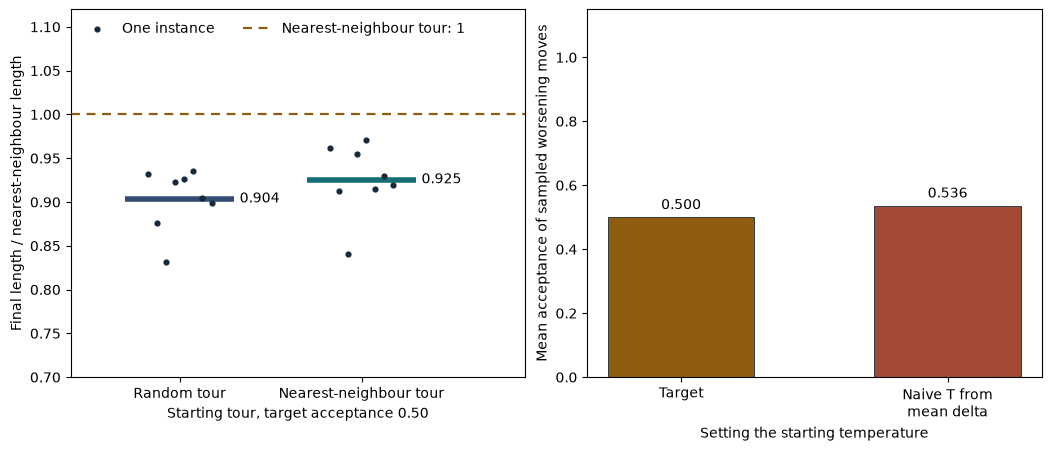

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch54 import draw, NCOLS, HEIGHT

DEFAULT = 0.5
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With a target acceptance of 0.50 and 60,000 moves, annealing from a random tour ends at 0.904 of the nearest-neighbour length and from the nearest-neighbour tour at 0.925, so the random start is shorter and 1 - 0.904 = 0.096 is the saving over no search. The temperature solved for this acceptance is 4.21 mean edge lengths for the random tour and 14.80 for the nearest-neighbour tour. Setting T from the mean worsening delta gives an acceptance of 0.536 instead of 0.50.

- Random start against nearest-neighbour start: 0.904 - 0.925 = -0.021 (negative means random is shorter).
- Saving of the better start over no search: 1 - 0.904 = 0.096.
- Naive temperature: acceptance 0.536 - target 0.50 = +0.036.
- Solved temperature for the random and the nearest-neighbour start: 4.21 and 14.80 mean edges.

## Apply this to your competition

- Sample worsening moves from the starting solution and solve for the temperature that gives a chosen acceptance, instead of copying a constant.
- Compare a few starting temperatures and both a cheap constructive start and a random start under the same number of evaluated moves.
- From a good constructive start, begin cool: a hot start discards the quality you paid for.
- Recompute the objective of the returned solution with the official scorer and keep the legal starting solution as the fallback.

Book location: Chapter 54, Simulated Annealing: The Most Robust Starting Point.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)